# Module 1 : Zero-Coupon Curve Bootstrapping from EUR Swap Rates

## Context
The market provides par swap rates, not zero-coupon rates directly.
A par swap of maturity T_N with fixed rate S_N satisfies:

S_N × Σ δᵢ × P(0,Tᵢ) + P(0,Tₙ) = 1

We solve **iteratively** for each discount factor P(0,Tᵢ).

## From Discount Factors to ZC Rates
r_zc(T) = -ln(P(0,T)) / T

## Instantaneous Forward Rate
f(0,T) = -d ln(P(0,T)) / dT

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [12]:
# EUR swap rates : representative of mid-2024 EUR IRS market
# Fixed leg: annual, Act/365
maturities  = np.array([1, 2, 3, 5, 7, 10], dtype=float)
swap_rates  = np.array([0.0370, 0.0340, 0.0320, 0.0310, 0.0308, 0.0310])

df_market = pd.DataFrame({
    "Maturity (Y)" : maturities,
    "Swap Rate (%)": swap_rates * 100
})

print("EUR Swap Rates (Input)")
print(df_market.to_string(index=False))

EUR Swap Rates (Input)
 Maturity (Y)  Swap Rate (%)
          1.0           3.70
          2.0           3.40
          3.0           3.20
          5.0           3.10
          7.0           3.08
         10.0           3.10


## Step 1 : Bootstrap the 1Y Discount Factor

For the first pillar (1 year), the swap has only one cash flow:
P(0,1) = 1 / (1 + S₁ × δ)

This is equivalent to a zero-coupon bond price.

In [3]:
delta = 1.0  # day count convention: annual Act/365

# P(0,1) = 1 / (1 + S_1 * delta)
P_1Y   = 1.0 / (1.0 + swap_rates[0] * delta)
r_1Y   = -np.log(P_1Y) / 1.0

print(f"Discount Factor P(0,1Y) = {P_1Y:.6f}")
print(f"ZC Rate r_zc(1Y)        = {r_1Y*100:.4f}%")

Discount Factor P(0,1Y) = 0.964320
ZC Rate r_zc(1Y)        = 3.6332%


## Step 2 : Bootstrap the 2Y Discount Factor

For the 2Y swap, there are two cash flows (at T=1 and T=2):
1 = S₂ × δ × P(0,1) + (1 + S₂ × δ) × P(0,2)

Solving for P(0,2):
P(0,2) = [1 - S₂ × δ × P(0,1)] / (1 + S₂ × δ)

In [4]:
S2   = swap_rates[1]
P_2Y = (1.0 - S2 * delta * P_1Y) / (1.0 + S2 * delta)
r_2Y = -np.log(P_2Y) / 2.0

print(f"Discount Factor P(0,2Y) = {P_2Y:.6f}")
print(f"ZC Rate r_zc(2Y)        = {r_2Y*100:.4f}%")

Discount Factor P(0,2Y) = 0.935409
ZC Rate r_zc(2Y)        = 3.3386%


## Step 3 : General Bootstrap Loop

For maturities beyond 2Y (including non-annual gaps like 3Y→5Y),
we solve iteratively. For intermediate annual dates not in our
pillar set (e.g. year 4 when jumping from 3Y to 5Y), we
interpolate discount factors log-linearly on already-known pillars.

General formula:
P(0,Tₙ) = [1 - Sₙ × Σᵢ₌₁ᴺ⁻¹ δ × P(0,Tᵢ)] / (1 + Sₙ × δ)

In [6]:
def interpolate_intermediate_dfs(t, known_T, known_df):
    """
    Log-linear interpolation on discount factors.
    For a date t not in known_T, interpolates between
    the two surrounding pillar points.
    
    Log-linear guarantees positive forward rates between pillars.
    
    Parameters
    ----------
    t        : float-target maturity
    known_T  : np.ndarray : already bootstrapped maturities
    known_df : np.ndarray : already bootstrapped discount factors
    """
    if t in known_T:
        idx = np.where(known_T == t)[0][0]
        return known_df[idx]
    
    if t <= known_T[0]:
        # Flat extrapolation for very short maturities
        r = -np.log(known_df[0]) / known_T[0]
        return np.exp(-r * t)
    
    if t > known_T[-1]:
        # Flat forward extrapolation beyond last known pillar
        r = -np.log(known_df[-1]) / known_T[-1]
        return np.exp(-r * t)
    
    # Standard log-linear interpolation
    i1 = np.searchsorted(known_T, t) - 1
    i2 = i1 + 1
    t1, t2   = known_T[i1], known_T[i2]
    df1, df2 = known_df[i1], known_df[i2]
    alpha    = (t - t1) / (t2 - t1)
    log_df   = (1 - alpha) * np.log(df1) + alpha * np.log(df2)
    return np.exp(log_df)

In [7]:
n_pillars       = len(maturities)
discount_factors = np.zeros(n_pillars)
zc_rates         = np.zeros(n_pillars)

# Pillar 1Y : already computed above
discount_factors[0] = P_1Y
zc_rates[0]         = r_1Y

# Loop over remaining pillars
for n in range(1, n_pillars):
    T_n    = maturities[n]
    S_n    = swap_rates[n]
    
    # All annual cash flow dates from 1Y to T_n
    annual_dates = np.arange(1, T_n + 1)
    
    # Known pillars so far
    known_T  = maturities[:n]
    known_df = discount_factors[:n]
    
    # Compute annuity = sum of discounted coupon payments (all except last)
    annuity = 0.0
    for t in annual_dates[:-1]:  # exclude final date T_n
        df_t     = interpolate_intermediate_dfs(t, known_T, known_df)
        annuity += delta * df_t
    
    # Solve for P(0, T_n)
    discount_factors[n] = (1.0 - S_n * annuity) / (1.0 + S_n * delta)
    zc_rates[n]         = -np.log(discount_factors[n]) / T_n
    
    print(f"T={T_n:4.0f}Y | P(0,T) = {discount_factors[n]:.6f} | r_zc = {zc_rates[n]*100:.4f}%")

T=   2Y | P(0,T) = 0.935409 | r_zc = 3.3386%
T=   3Y | P(0,T) = 0.910086 | r_zc = 3.1405%
T=   5Y | P(0,T) = 0.858929 | r_zc = 3.0414%
T=   7Y | P(0,T) = 0.809186 | r_zc = 3.0247%
T=  10Y | P(0,T) = 0.737131 | r_zc = 3.0499%


In [11]:
results = pd.DataFrame({
    "Maturity (Y)"    : maturities,
    "Swap Rate (%)"   : swap_rates * 100,
    "Discount Factor" : np.round(discount_factors, 6),
    "ZC Rate (%)"     : np.round(zc_rates * 100, 4),
})

print("Bootstrapped Zero-Coupon Curve")
print(results.to_string(index=False))

Bootstrapped Zero-Coupon Curve
 Maturity (Y)  Swap Rate (%)  Discount Factor  ZC Rate (%)
          1.0           3.70         0.964320       3.6332
          2.0           3.40         0.935409       3.3386
          3.0           3.20         0.910086       3.1405
          5.0           3.10         0.858929       3.0414
          7.0           3.08         0.809186       3.0247
         10.0           3.10         0.737131       3.0499


In [13]:
def get_discount_factor(T, maturities, discount_factors):
    """
    Returns interpolated discount factor P(0,T) for any maturity T.
    Uses log-linear interpolation on pillar discount factors.
    """
    log_dfs = np.log(discount_factors)
    log_df  = np.interp(T, maturities, log_dfs)
    return np.exp(log_df)

def get_zc_rate(T, maturities, discount_factors):
    """
    Returns continuously compounded ZC rate r_zc(T).
    """
    df = get_discount_factor(T, maturities, discount_factors)
    return -np.log(df) / T

def get_forward_rate(T1, T2, maturities, discount_factors):
    """
    Returns simply-compounded forward rate f(T1, T2).
    This is the rate used to price each Caplet in Module 2.
    
    f(T1,T2) = [P(0,T1)/P(0,T2) - 1] / (T2 - T1)
    """
    df1 = get_discount_factor(T1, maturities, discount_factors)
    df2 = get_discount_factor(T2, maturities, discount_factors)
    return (df1 / df2 - 1.0) / (T2 - T1)

def get_instantaneous_forward(T, maturities, discount_factors, h=1e-4):
    """
    Instantaneous forward rate f(0,T) by central finite differences:
    f(0,T) ≈ -[ln P(0,T+h) - ln P(0,T-h)] / (2h)
    """
    T_lo = max(T - h, 1e-6)
    T_hi = T + h
    log_lo = np.log(get_discount_factor(T_lo, maturities, discount_factors))
    log_hi = np.log(get_discount_factor(T_hi, maturities, discount_factors))
    return -(log_hi - log_lo) / (T_hi - T_lo)

print("Utility functions defined successfully.")

Utility functions defined successfully.


In [14]:
print("Simply-Compounded Forward Rates (Caplet inputs)")
caplet_schedule = [(i, i+0.5) for i in np.arange(1.0, 5.0, 0.5)]

for T1, T2 in caplet_schedule:
    f = get_forward_rate(T1, T2, maturities, discount_factors)
    print(f"  f({T1:.1f}Y, {T2:.1f}Y) = {f*100:.4f}%")

Simply-Compounded Forward Rates (Caplet inputs)
  f(1.0Y, 1.5Y) = 3.0672%
  f(1.5Y, 2.0Y) = 3.0672%
  f(2.0Y, 2.5Y) = 2.7634%
  f(2.5Y, 3.0Y) = 2.7634%
  f(3.0Y, 3.5Y) = 2.9137%
  f(3.5Y, 4.0Y) = 2.9137%
  f(4.0Y, 4.5Y) = 2.9137%
  f(4.5Y, 5.0Y) = 2.9137%


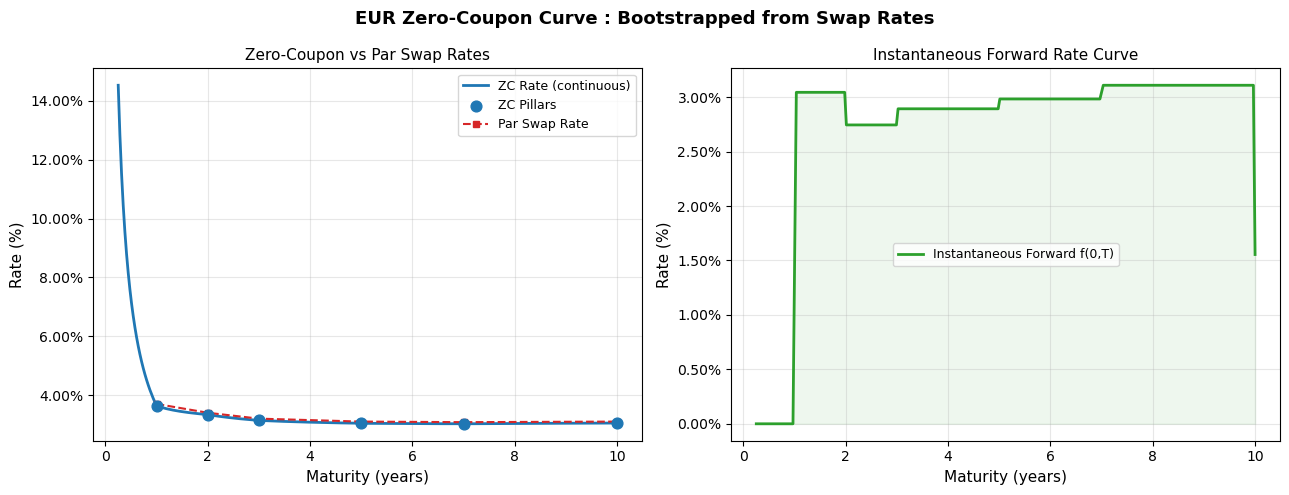

Figure saved to outputs/curve_output.png


In [16]:
fine_grid = np.linspace(0.25, 10, 300)

zc_fine  = [get_zc_rate(T, maturities, discount_factors) * 100 for T in fine_grid]
fwd_fine = [get_instantaneous_forward(T, maturities, discount_factors) * 100 for T in fine_grid]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("EUR Zero-Coupon Curve : Bootstrapped from Swap Rates",
             fontsize=13, fontweight="bold")

# Panel 1: ZC vs Swap rates 
ax = axes[0]
ax.plot(fine_grid, zc_fine, color="#1f77b4", lw=2, label="ZC Rate (continuous)")
ax.scatter(maturities, zc_rates*100, color="#1f77b4", zorder=5, s=60, label="ZC Pillars")
ax.plot(maturities, swap_rates*100, color="#d62728", lw=1.5,
        linestyle="--", marker="s", markersize=5, label="Par Swap Rate")
ax.set_xlabel("Maturity (years)", fontsize=11)
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Zero-Coupon vs Par Swap Rates", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Instantaneous forward
ax = axes[1]
ax.plot(fine_grid, fwd_fine, color="#2ca02c", lw=2, label="Instantaneous Forward f(0,T)")
ax.fill_between(fine_grid, fwd_fine, alpha=0.08, color="#2ca02c")
ax.set_xlabel("Maturity (years)", fontsize=11)
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Instantaneous Forward Rate Curve", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/curve_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs/curve_output.png")